# 1단계: 데이터 로드 및 전처리

In [2]:
import pandas as pd
import os

# 1. 경로 설정 (상대 경로 사용)
# 현재 ipynb 파일 위치를 기준으로 'data' 폴더 안의 파일을 지정합니다.
file_path = os.path.join("data", "NFLX.csv")

# 2. 데이터 불러오기
try:
    df = pd.read_csv(file_path)
    print("✅ 데이터를 성공적으로 불러왔습니다!")
    
    # 데이터 상위 5개 미리보기
    print(df.head())
    
    # 데이터 기본 정보 확인 (컬럼명, 데이터 개수 등)
    print(df.info())

except FileNotFoundError:
    print(f"❌ 파일을 찾을 수 없습니다. 경로를 확인해주세요: {file_path}")
    print("현재 폴더 내 파일 목록:", os.listdir())

✅ 데이터를 성공적으로 불러왔습니다!
         Date        Open        High         Low       Close   Adj Close  \
0  2018-02-05  262.000000  267.899994  250.029999  254.259995  254.259995   
1  2018-02-06  247.699997  266.700012  245.000000  265.720001  265.720001   
2  2018-02-07  266.579987  272.450012  264.329987  264.559998  264.559998   
3  2018-02-08  267.079987  267.619995  250.000000  250.100006  250.100006   
4  2018-02-09  253.850006  255.800003  236.110001  249.470001  249.470001   

     Volume  
0  11896100  
1  12595800  
2   8981500  
3   9306700  
4  16906900  
<class 'pandas.DataFrame'>
RangeIndex: 1009 entries, 0 to 1008
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       1009 non-null   str    
 1   Open       1009 non-null   float64
 2   High       1009 non-null   float64
 3   Low        1009 non-null   float64
 4   Close      1009 non-null   float64
 5   Adj Close  1009 non-null   float64
 6   Volume     1

# 2단계: 데이터 전처리 및 시퀀스 생성

In [3]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import torch

# 1. 'Close'(종가) 데이터만 추출하여 0~1 사이로 스케일링
scaler = MinMaxScaler()
closed_prices = df['Close'].values.reshape(-1, 1)
scaled_data = scaler.fit_transform(closed_prices)

# 2. 시퀀스 데이터 만드는 함수 정의
def create_sequences(data, seq_length):
    x_list, y_list = [], []
    for i in range(len(data) - seq_length):
        x = data[i : i + seq_length] # 과거 7일치 데이터 (입력 X)
        y = data[i + seq_length]     # 다음 날 데이터 (정답 y)
        x_list.append(x)
        y_list.append(y)
    return np.array(x_list), np.array(y_list)

# 3. 데이터 세트 생성 (과거 7일을 보고 다음 날 예측)
seq_length = 7 
X, y = create_sequences(scaled_data, seq_length)

# 4. 학습용(80%)과 테스트용(20%)으로 나누기
split = int(len(X) * 0.8)

# 파이토치에서 사용할 수 있도록 텐서(Tensor) 형태로 변환
X_train = torch.FloatTensor(X[:split])
y_train = torch.FloatTensor(y[:split])
X_test = torch.FloatTensor(X[split:])
y_test = torch.FloatTensor(y[split:])

print(f"학습용 데이터 개수: {len(X_train)}")
print(f"테스트용 데이터 개수: {len(X_test)}")
print(f"데이터의 형태 (X_train): {X_train.shape}") # [데이터수, 7, 1]

학습용 데이터 개수: 801
테스트용 데이터 개수: 201
데이터의 형태 (X_train): torch.Size([801, 7, 1])


# 3단계: LSTM 모델 정의

In [4]:
import torch.nn as nn
import torch.optim as optim

# 1. LSTM 모델 클래스 정의
class StockPredictor(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.hidden_size = hidden_size
        
        # LSTM 레이어: 정보를 기억하는 장치
        # batch_first=True는 데이터 형태가 (배치, 7일, 1개종가)임을 알려줍니다.
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
        
        # 출력 레이어: LSTM이 기억한 정보를 바탕으로 최종 가격 1개를 예측
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # x shape: (batch, seq_len, input_size)
        # out: 모든 시점의 출력값, _ : 은닉 상태(사용 안 함)
        out, _ = self.lstm(x)
        
        # 마지막 날(7일째)의 기억 정보만 사용하여 다음 날 가격 예측
        out = self.fc(out[:, -1, :])
        return out

# 2. 모델 객체 생성
# input_size=1 (종가 1개), hidden_size=64 (기억 유닛 64개), output_size=1 (내일 가격 1개)
model = StockPredictor(input_size=1, hidden_size=64, output_size=1)

# 3. 손실 함수와 최적화 도구 설정
criterion = nn.MSELoss() # 예측값과 실제값의 차이(오차)를 계산 (평균제곱오차)
optimizer = optim.Adam(model.parameters(), lr=0.001) # 오차를 줄여나가는 학습 도구 (Adam)

print(model)

StockPredictor(
  (lstm): LSTM(1, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)


# 4. 모델학습

In [5]:
# 1. 학습 파라미터 설정
epochs = 100  # 전체 데이터를 100번 반복 학습
train_losses = [] # 오차 변화를 저장할 리스트

# 2. 본격적인 학습 루프 시작
for epoch in range(epochs):
    model.train() # 모델을 학습 모드로 전환
    
    # 기울기(Gradient) 초기화 (새로운 학습 단계마다 비워줘야 함)
    optimizer.zero_grad()
    
    # 모델에 입력 데이터 전달 (예측 수행)
    outputs = model(X_train)
    
    # 예측값과 실제값(정답) 사이의 오차 계산
    loss = criterion(outputs, y_train)
    
    # 역전파(Backpropagation): 오차를 바탕으로 모델 수정 방향 계산
    loss.backward()
    
    # 가중치 업데이트: 실제로 모델의 '뇌'를 수정
    optimizer.step()
    
    # 오차 기록
    train_losses.append(loss.item())
    
    # 10회마다 학습 상태 출력
    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.6f}")

print("✅ 학습이 완료되었습니다!")

Epoch [10/100], Loss: 0.075670
Epoch [20/100], Loss: 0.028544
Epoch [30/100], Loss: 0.027643
Epoch [40/100], Loss: 0.020979
Epoch [50/100], Loss: 0.016563
Epoch [60/100], Loss: 0.011406
Epoch [70/100], Loss: 0.005195
Epoch [80/100], Loss: 0.001848
Epoch [90/100], Loss: 0.002250
Epoch [100/100], Loss: 0.001785
✅ 학습이 완료되었습니다!


# 5. 예측 및 시각화

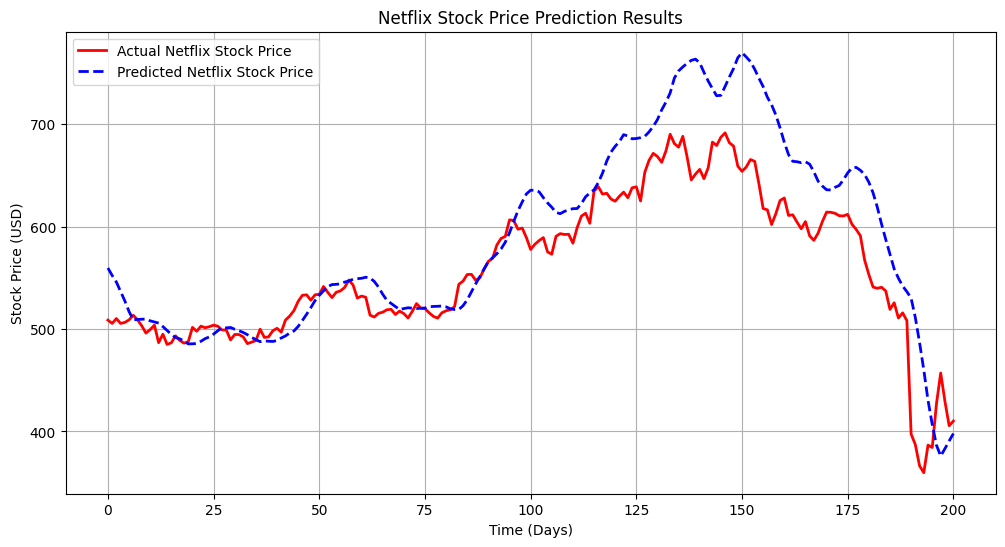

✅ 평균 오차율(MAPE): 6.08%


In [6]:
import matplotlib.pyplot as plt

# 1. 모델을 평가 모드로 전환 (학습 중지)
model.eval()

# 2. 테스트 데이터로 예측 수행 (기울기 계산 필요 없음)
with torch.no_grad():
    test_predict = model(X_test)

# 3. 0~1로 압축됐던 데이터를 다시 원래 주가(달러)로 복구
# scaler.inverse_transform을 사용합니다.
predict_prices = scaler.inverse_transform(test_predict.numpy())
actual_prices = scaler.inverse_transform(y_test.numpy())

# 4. 결과 시각화 (그래프 그리기)
plt.figure(figsize=(12, 6))

# 실제 주가 (빨간색)
plt.plot(actual_prices, label='Actual Netflix Stock Price', color='red', linewidth=2)

# 모델의 예측 주가 (파란색 점선)
plt.plot(predict_prices, label='Predicted Netflix Stock Price', color='blue', linestyle='--', linewidth=2)

plt.title('Netflix Stock Price Prediction Results')
plt.xlabel('Time (Days)')
plt.ylabel('Stock Price (USD)')
plt.legend()
plt.grid(True)
plt.show()

# 5. 오차율 확인 (평균 절대 오차율)
mape = np.mean(np.abs((actual_prices - predict_prices) / actual_prices)) * 100
print(f"✅ 평균 오차율(MAPE): {mape:.2f}%")

# 야후 데이터 불러와서 실제 주가와 비교

In [7]:
pip install yfinance

  Using cached multitasking-0.0.12.tar.gz (19 kB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Using cached pytz-2026.1.post1-py2.py3-none-any.whl.metadata (22 kB)
  Using cached beautifulsoup4-4.14.3-py3-none-any.whl.metadata (3.8 kB)
  Using cached curl_cffi-0.13.0-cp39-abi3-win_amd64.whl.metadata (13 kB)
  Using cached soupsieve-2.8.3-py3-none-any.whl.metadata (4.6 kB)
Using cached curl_cffi-0.13.0-cp39-abi3-win_amd64.whl (1.6 MB)
Using cached beautifulsoup4-4.14.3-py3-none-any.whl (107 kB)
Using cached pytz-2026.1.post1-py2.py3-none-any.whl (510 kB)
Using cached soupsieve-2.8.3-py3-none-any.whl (37 kB)
  Created wheel for multitasking: filename=multitasking-0.0.12-py3-none-any.whl size=15702 sha256=c

## 1. 야후 데이터 로드 및 전처리

In [10]:
import yfinance as yf
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import torch

# 1. 넷플릭스 전체 데이터 가져오기 (2020년부터 오늘까지)
df = yf.download("NFLX", start="2020-01-01", end=datetime.now().strftime('%Y-%m-%d'))
data = df['Close'].values.reshape(-1, 1)

# 2. 스케일러 설정 및 변환
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

# 3. 시퀀스 생성 (7일치 보고 8일째 예측)
def create_sequences(data, seq_length):
    xs, ys = [], []
    for i in range(len(data) - seq_length):
        xs.append(data[i:i+seq_length])
        ys.append(data[i+seq_length])
    return np.array(xs), np.array(ys)

X, y = create_sequences(scaled_data, 7)
X_train = torch.FloatTensor(X)
y_train = torch.FloatTensor(y)

[*********************100%***********************]  1 of 1 completed


# 2. 모델 재학습

In [11]:
import torch.optim as optim

# 1. 모델 객체 재생성 (입력 1개, 히든 64개, 출력 1개)
model = StockPredictor(input_size=1, hidden_size=64, output_size=1)

# 2. 손실 함수 및 최적화 도구 설정
criterion = nn.MSELoss() 
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 3. 학습 루프 (100번 반복)
epochs = 100
train_losses = []

print("🚀 최신 데이터로 모델 학습을 시작합니다...")

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    
    # 데이터 입력 및 예측
    outputs = model(X_train)
    loss = criterion(outputs, y_train)
    
    # 역전파 및 가중치 업데이트
    loss.backward()
    optimizer.step()
    
    train_losses.append(loss.item())
    
    if (epoch + 1) % 20 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.6f}")

print("✅ 학습 완료! 이제 최신 주가 흐름을 반영한 모델이 준비되었습니다.")

🚀 최신 데이터로 모델 학습을 시작합니다...
Epoch [20/100], Loss: 0.045128
Epoch [40/100], Loss: 0.033305
Epoch [60/100], Loss: 0.014319
Epoch [80/100], Loss: 0.001776
Epoch [100/100], Loss: 0.001405
✅ 학습 완료! 이제 최신 주가 흐름을 반영한 모델이 준비되었습니다.


# 3. 실시간 데이터 시각화 및 내일의 주가 예측

[*********************100%***********************]  1 of 1 completed


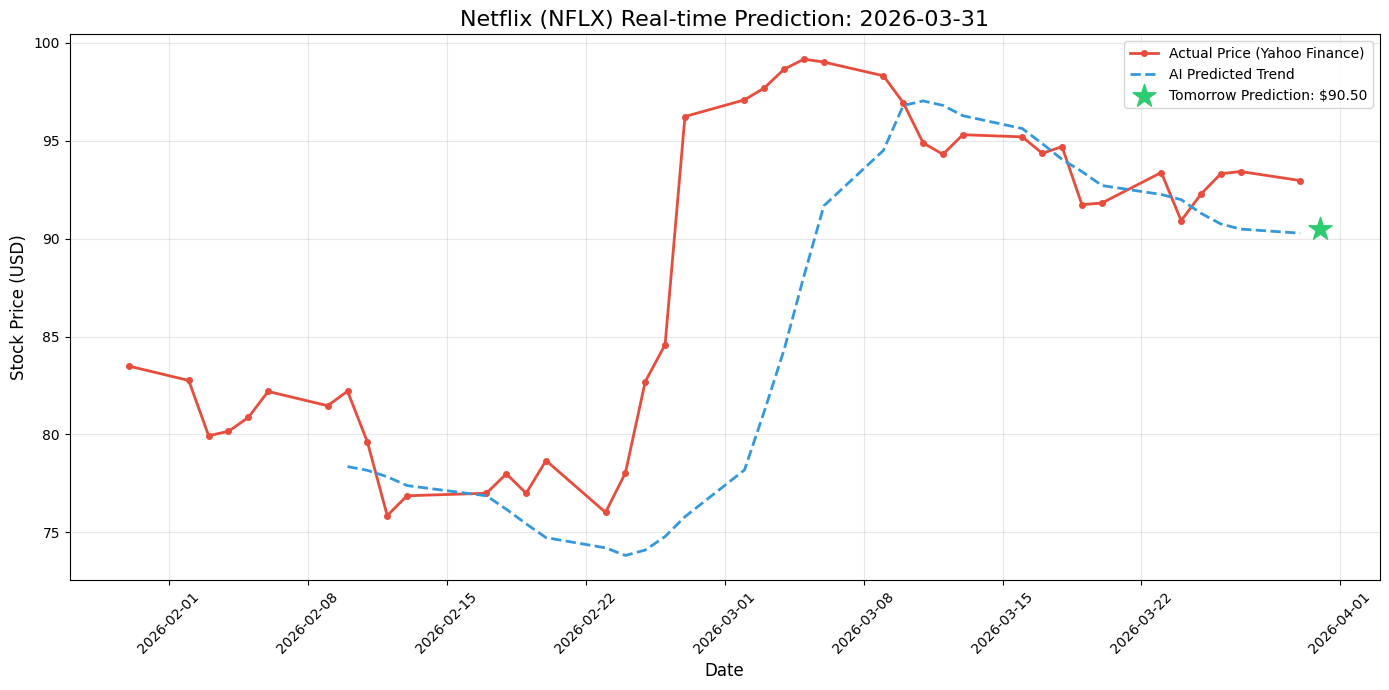

📢 오늘 최종 종가: $92.97
🚀 AI가 예측한 내일 종가: $90.50


In [12]:
import yfinance as yf
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

# 1. 최신 데이터 가져오기 (최근 60일치)
ticker = "NFLX"
end_date = datetime.now().strftime('%Y-%m-%d')
start_date = (datetime.now() - timedelta(days=60)).strftime('%Y-%m-%d')
recent_df = yf.download(ticker, start=start_date, end=end_date)

# 2. 데이터 전처리 (방금 학습에 쓴 scaler 그대로 사용!)
recent_closed = recent_df['Close'].values.reshape(-1, 1)
recent_scaled = scaler.transform(recent_closed)

# 3. 모델 예측 수행 (최근 7일 데이터를 슬라이딩하며 예측)
model.eval()
predictions = []

with torch.no_grad():
    for i in range(len(recent_scaled) - 7):
        seq = torch.FloatTensor(recent_scaled[i:i+7]).view(1, 7, 1)
        pred = model(seq)
        predictions.append(pred.item())

    # 4. 가장 중요한 '내일(Tomorrow)' 예측
    last_seq = torch.FloatTensor(recent_scaled[-7:]).view(1, 7, 1)
    tomorrow_pred_scaled = model(last_seq)
    tomorrow_price = scaler.inverse_transform(tomorrow_pred_scaled.numpy())[0][0]

# 5. 시각화를 위해 원래 가격으로 복구
predicted_prices = scaler.inverse_transform(np.array(predictions).reshape(-1, 1))

# 6. 그래프 그리기
plt.figure(figsize=(14, 7))

# [빨간색] 실제 주가
plt.plot(recent_df.index, recent_closed, label='Actual Price (Yahoo Finance)', color='#e74c3c', linewidth=2, marker='o', markersize=4)

# [파란색 점선] 모델의 예측 추세 (날짜를 맞추기 위해 index[7:] 사용)
plt.plot(recent_df.index[7:], predicted_prices, label='AI Predicted Trend', color='#3498db', linestyle='--', linewidth=2)

# [초록색 별] 내일의 주가 예측점
tomorrow_date = recent_df.index[-1] + timedelta(days=1)
plt.scatter(tomorrow_date, tomorrow_price, color='#2ecc71', marker='*', s=300, label=f'Tomorrow Prediction: ${tomorrow_price:.2f}', zorder=5)

# 그래프 설정
plt.title(f'Netflix ({ticker}) Real-time Prediction: {datetime.now().strftime("%Y-%m-%d")}', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Stock Price (USD)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f"📢 오늘 최종 종가: ${recent_closed[-1][0]:.2f}")
print(f"🚀 AI가 예측한 내일 종가: ${tomorrow_price:.2f}")

# 4. 정확도, 정밀도 체크

In [13]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. 테스트 데이터에 대한 예측 수행
model.eval()
with torch.no_grad():
    y_pred_scaled = model(X_test)
    # 원래 가격 단위(USD)로 복구
    y_pred = scaler.inverse_transform(y_pred_scaled.numpy())
    y_true = scaler.inverse_transform(y_test.numpy())

# 2. 주요 평가지표 계산
mae = mean_absolute_error(y_true, y_pred) # 평균 절대 오차 (실제 가격과 몇 달러 차이나는지)
rmse = np.sqrt(mean_squared_error(y_true, y_pred)) # 루트 평균 제곱 오차 (큰 오차에 가중치)
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100 # 평균 절대 오차율 (%)
r2 = r2_score(y_true, y_pred) # 결정계수 (1에 가까울수록 완벽한 모델)

print("--- 넷플릭스 주가 예측 모델 성적표 ---")
print(f"1. 평균 오차 (MAE): ${mae:.2f}")
print(f"2. 오차율 (MAPE): {mape:.2f}%")
print(f"3. 결정계수 (R²): {r2:.4f}")

--- 넷플릭스 주가 예측 모델 성적표 ---
1. 평균 오차 (MAE): $5.09
2. 오차율 (MAPE): 5.62%
3. 결정계수 (R²): 0.8491
